

# Abatacept responders and Non- responders DEGs volcano plot

In [1]:

# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library(tidyverse)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(Matrix)
quiet_library(dplyr)
quiet_library(viridis)
quiet_library(harmony)
quiet_library(future)
quiet_library(future.apply)
quiet_library(SingleCellExperiment)
quiet_library(SeuratDisk)
quiet_library(ggpubr)
quiet_library(knitr)
quiet_library(plotly)
quiet_library(lme4)
quiet_library(ggpubr)
quiet_library(qvalue)
quiet_library(ggrepel)

Warning message:
“package ‘qvalue’ was built under R version 4.3.2”


In [2]:
# Check number of cores
future::availableCores()
# Set up parallel processing to run when using 'future' functions 
future::plan(strategy = "multicore", workers = future::availableCores()-5)  
options(future.globals.maxSize = 1000 * 1024^3)
# to turn off parallel processing run line below
# future::plan(strategy = "sequential")

system 
    64

In [3]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
coolors_clrs<-c("#EFB0A1","#009FF5","#1A5E9B","#42E2B8","#4ECDC4","#89B6A5","#F1D26A","#D5B0AC","#EDABB1","#02504D","#AA9674","#E64B35FF","#4DBBD5FF","#00A087FF")

cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width =5, repr.plot.height =5)

In [4]:
fig_path="/home/jupyter/ALTRA_ANALYSIS/Deep_clean/Figure_files/Certpro_figures/Plots_for_manuscript/"

# Figure 7B 


In [32]:
abt_deg=read.csv("/home/jupyter/ALTRA_ANALYSIS/Deep_clean/Figure_notebooks/files/input_files/abatacept/ALTRA_AIM3_scRNA_validation_responder_pre_post_degs.csv")
abt_deg%>%dim
abt_deg%>%head(3)

[1] 13608     7

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,18.36329,-0.04054009,0.4435564,-0.09139784,0.9271765,0.6894360
2,DPM1,498.47598,-0.14877090,0.1898690,-0.78354501,0.4333071,0.5231215
3,SCYL3,454.06455,-0.09370180,0.1282288,-0.73073902,0.4649386,0.5368994


In [33]:

abt_deg<- abt_deg %>%
  mutate(logfc_by_year= log2FoldChange * 365)

abt_deg%>%dim
abt_deg%>%head(3)

[1] 13608     8

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,logfc_by_year
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,18.36329,-0.04054009,0.4435564,-0.09139784,0.9271765,0.6894360,-14.79713
2,DPM1,498.47598,-0.14877090,0.1898690,-0.78354501,0.4333071,0.5231215,-54.30138
3,SCYL3,454.06455,-0.09370180,0.1282288,-0.73073902,0.4649386,0.5368994,-34.20116


In [34]:
filtered_df=abt_deg %>% 
    dplyr::filter(q_values<0.1)%>%arrange(q_values)
filtered_df%>%head(3)
filtered_df%>%dim

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,logfc_by_year
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,EEF2,6952.00020,1.252571,0.1395632,8.974941,2.835033e-19,2.722390e-15,457.1885
2,PRAF2,194.08018,1.801119,0.2344268,7.683079,1.553102e-14,7.456970e-11,657.4086
3,CLIC3,50.67315,3.075168,0.4147460,7.414582,1.220088e-13,3.905371e-10,1122.4364


[1] 965   8

In [35]:
filtered_df=filtered_df[1:30,]
filtered_df

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,logfc_by_year
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,EEF2,6952.00020,1.2525712,0.1395632,8.974941,2.835033e-19,2.722390e-15,457.1885
2,PRAF2,194.08018,1.8011195,0.2344268,7.683079,1.553102e-14,7.456970e-11,657.4086
3,CLIC3,50.67315,3.0751681,0.4147460,7.414582,1.220088e-13,3.905371e-10,1122.4364
4,SQSTM1,1329.60006,1.3168178,0.1838929,7.160788,8.021470e-13,1.925690e-09,480.6385
5,PFKL,194.63331,1.2004577,0.1789514,6.708289,1.969194e-11,3.781907e-08,438.1671
6,PTPRCAP,466.60068,1.1370015,0.1785860,6.366689,1.931522e-10,3.091297e-07,415.0056
7,CYBA,405.35347,1.7318728,0.2759109,6.276928,3.453286e-10,3.929169e-07,632.1336
8,CRY2,183.01056,1.0278227,0.1642077,6.259284,3.867496e-10,3.929169e-07,375.1553
9,PRSS23,481.93612,1.3893919,0.2218286,6.263358,3.767748e-10,3.929169e-07,507.1280


In [36]:
abt_deg%>%dim

[1] 13608     8

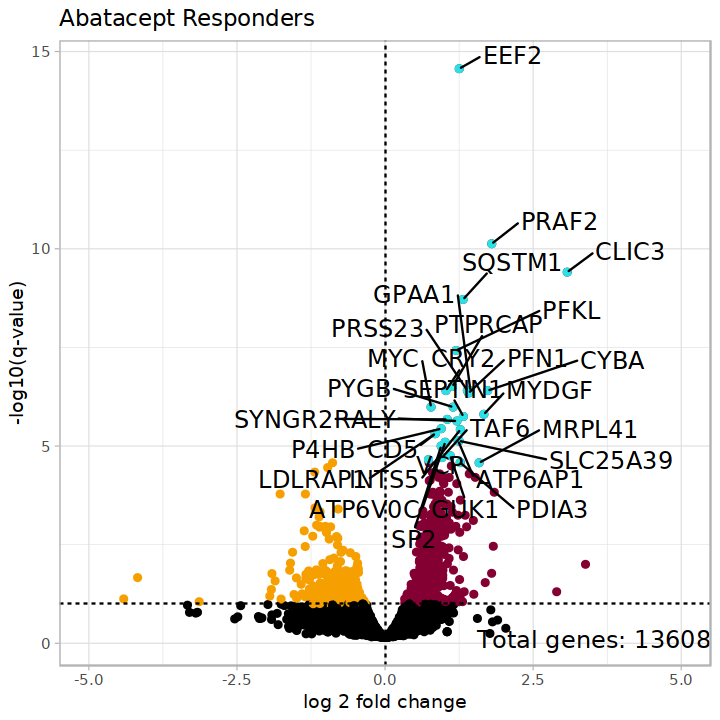

In [38]:
plot_custom_volcano(data = abt_deg, logfc_column = "log2FoldChange", pval_column = "p.value", 
             padj_column = "q_values", gene_column = "gene", filtered_genes = filtered_df, 
             title = "Abatacept Responders", x_label = "log 2 fold change", y_label = "-log10(q-value)",
             x_limits = c(-5,5), 
                   # y_limits = c(0, 20), 
                    max_overlaps = 35,
             file_path = fig_path, file_name = "Fig_7B.pdf"
                   )

# Figure 7D

In [39]:
abt_non_deg=read.csv("/home/jupyter/ALTRA_ANALYSIS/Deep_clean/Figure_notebooks/files/input_files/abatacept/ALTRA_AIM3_scRNA_validation_nonresponder_pre_post_degs.csv")
abt_non_deg%>%dim
abt_non_deg%>%head(3)

[1] 13275     7

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,DPM1,379.14259,-0.05712159,0.1720638,-0.3319792,0.7399050,0.9552337
2,SCYL3,343.65831,0.02574844,0.1391630,0.1850236,0.8532105,0.9655959
3,C1orf112,71.51417,-0.04306472,0.2046950,-0.2103848,0.8333674,0.9647510


In [40]:
abt_non_deg<- abt_non_deg %>%
  mutate(logfc_by_year= log2FoldChange * 365)

abt_non_deg%>%dim
abt_non_deg%>%head(3)

[1] 13275     8

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,logfc_by_year
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,DPM1,379.14259,-0.05712159,0.1720638,-0.3319792,0.7399050,0.9552337,-20.849379
2,SCYL3,343.65831,0.02574844,0.1391630,0.1850236,0.8532105,0.9655959,9.398182
3,C1orf112,71.51417,-0.04306472,0.2046950,-0.2103848,0.8333674,0.9647510,-15.718622


In [41]:
filtered_non_df=abt_non_deg %>% 
    dplyr::filter(q_values<0.1)%>%arrange(q_values)
filtered_non_df%>%head(3)
filtered_non_df%>%dim

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,logfc_by_year
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TDRD9,129.29138,-0.8628368,0.1762981,-4.894193,9.871009e-07,0.007616922,-314.9354
2,PCLAF,80.88858,-1.0818436,0.2226591,-4.858744,1.181325e-06,0.007616922,-394.8729
3,CREG1,221.21100,-0.5992515,0.1259881,-4.756413,1.970634e-06,0.008470805,-218.7268


[1] 25  8

In [42]:
filtered_non_df=filtered_non_df[1:25,]
filtered_non_df

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,logfc_by_year
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TDRD9,129.29138,-0.8628368,0.17629809,-4.894193,9.871009e-07,0.007616922,-314.9354
2,PCLAF,80.88858,-1.0818436,0.22265909,-4.858744,1.181325e-06,0.007616922,-394.8729
3,CREG1,221.21100,-0.5992515,0.12598811,-4.756413,1.970634e-06,0.008470805,-218.7268
4,METTL7B,75.44486,-1.6168274,0.36137586,-4.474088,7.673814e-06,0.024739520,-590.1420
5,HMGB3,85.42244,-0.7751012,0.17705858,-4.377654,1.199637e-05,0.028174825,-282.9119
6,SIGLEC17P,319.32190,0.4528297,0.10390110,4.358276,1.310909e-05,0.028174825,165.2828
7,NUP42,538.49685,-0.2927606,0.06894644,-4.246202,2.174242e-05,0.040054359,-106.8576
8,SERPINB10,193.49473,-0.9163811,0.21854615,-4.193078,2.751943e-05,0.044359787,-334.4791
9,METTL9,529.91879,-0.4244219,0.10230767,-4.148485,3.346822e-05,0.047954581,-154.9140


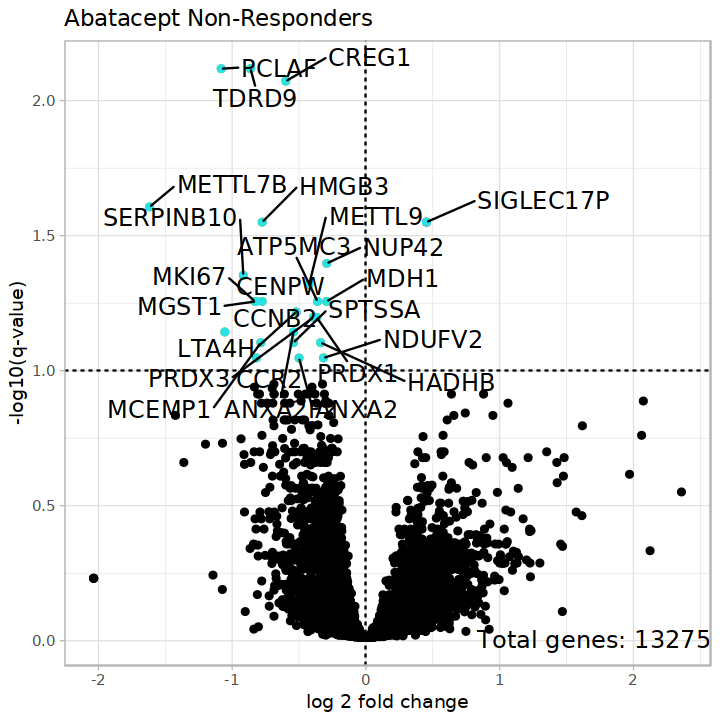

In [43]:
plot_custom_volcano(data = abt_non_deg, logfc_column = "log2FoldChange", pval_column = "p.value", 
             padj_column = "q_values", gene_column = "gene", filtered_genes = filtered_non_df, 
             title = "Abatacept Non-Responders", x_label = "log 2 fold change", y_label = "-log10(q-value)",
             #x_limits = c(-5,5), 
                   # y_limits = c(0, 20), 
                    max_overlaps = 35,
             file_path = fig_path, file_name = "Fig_7D.pdf"
                   )

In [44]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /home/jupyter/libs/r_scrna/lib/libopenblasp-r0.3.24.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggeffects_1.7.0             lmerTest_3.1-3             
 [3] ggrepel_0.9.5               qvalue_2.34.0              
 [5] lme4_1.1-34                 plotly_4.10.4              
 [7] knitr_1.47                  ggpubr_0.6.0               
 [9] SeuratDisk_0.0.0.9021       Single